In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean/AAPL_clean.csv')
print(df.head())
print(df.shape)

         date  open_price  high_price  low_price  close_price    volume
0  2025-09-29     254.560     255.000     253.01       254.43  40127687
1  2025-09-30     254.855     255.919     253.11       254.63  37704259
2  2025-10-01     255.040     258.790     254.93       255.45  48713940
3  2025-10-02     256.575     258.180     254.15       257.13  42630239
4  2025-10-03     254.665     259.240     253.95       258.02  49155614
(100, 6)


In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Missing values:
date           0
open_price     0
high_price     0
low_price      0
close_price    0
volume         0
dtype: int64

Duplicates: 0


In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

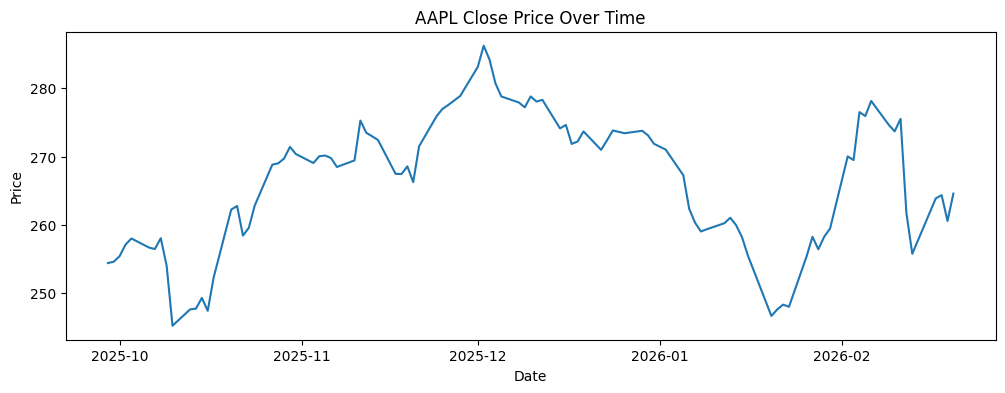

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['close_price'])
plt.title('AAPL Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

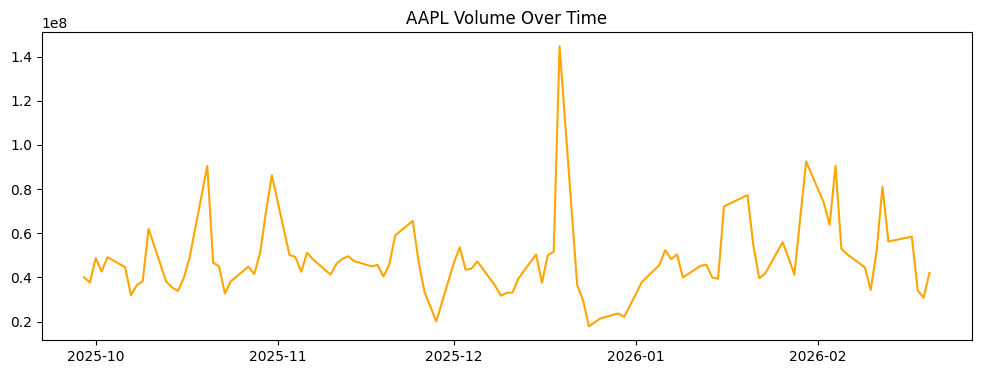

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['volume'], color='orange')
plt.title('AAPL Volume Over Time')
plt.show()

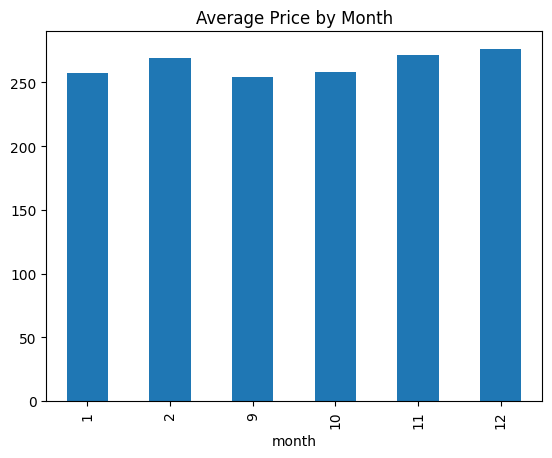

In [6]:
df['month'] = df['date'].dt.month
monthly = df.groupby('month')['close_price'].mean()
monthly.plot(kind='bar', title='Average Price by Month')
plt.show()

In [7]:
top5 = df.nlargest(5, 'close_price')[['date','close_price']]
bottom5 = df.nsmallest(5, 'close_price')[['date','close_price']]
print("Top 5 days:\n", top5)
print("\nBottom 5 days:\n", bottom5)

Top 5 days:
          date  close_price
45 2025-12-02       286.19
46 2025-12-03       284.15
44 2025-12-01       283.10
47 2025-12-04       280.70
43 2025-11-28       278.85

Bottom 5 days:
          date  close_price
9  2025-10-10       245.27
77 2026-01-20       246.70
13 2025-10-16       247.45
78 2026-01-21       247.65
10 2025-10-13       247.66


In [8]:
df['daily_change'] = df['close_price'].pct_change()
trend = df['close_price'].iloc[-1] - df['close_price'].iloc[0]
print("Overall trend (+ = going up):", round(trend, 2))
print("\nBiggest single-day moves:")
print(df[['date','daily_change']].reindex(df['daily_change'].abs().nlargest(5).index))

Overall trend (+ = going up): 10.15

Biggest single-day moves:
         date  daily_change
94 2026-02-12     -0.049982
86 2026-02-02      0.040581
15 2025-10-20      0.039439
77 2026-01-20     -0.034556
9  2025-10-10     -0.034522
